# Scheme B: Model outputs scalar estimating the number of components (K)



In [1]:
# Assumes: pip install -e . from project root

In [2]:
### Imports
import numpy as np
import torch
import matplotlib.pyplot as plt
from spectackle.config import deep_update, set_cpu_safety
from spectackle.data import BASE_CFG, make_loaders
from spectackle.models import CountNet1DDeep
from spectackle.training import train_scheme_b
from spectackle.plotting import plot_example, collect_count_predictions_b
set_cpu_safety(1)  ### Avoid CPU oversubscription on macOS


In [3]:
### Config + data (from spectackle)
cfg = deep_update(BASE_CFG, {})
Kmax = int(cfg["max_components"])
train_loader, val_loader = make_loaders(cfg)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Kmax={Kmax}, device={device}")

Kmax=10, device=cpu


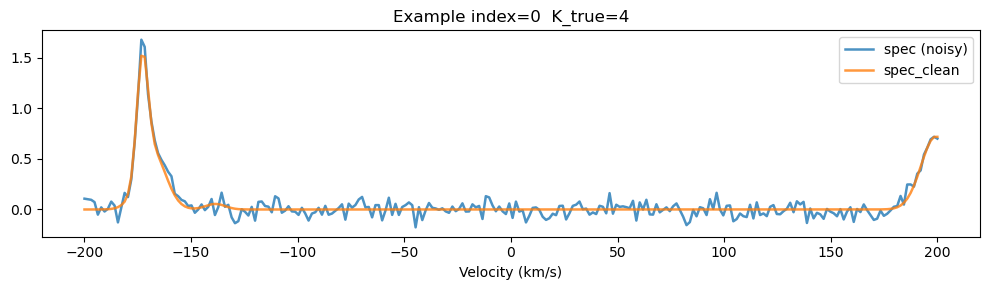

In [4]:
### Plot one example spectrum
plot_example(val_loader.dataset, idx=0)


In [5]:
### Model: deeper CNN with BatchNorm (from spectackle)
model = CountNet1DDeep(width=96, n_blocks=6)


In [6]:
### Train (spectackle: grad_clip + CosineAnnealingLR for stability)
model = train_scheme_b(
    model, train_loader, val_loader,
    device=device, lr=1e-3, epochs=8, log_every=200, Kmax=Kmax,
    grad_clip=1.0, use_scheduler=True,
)


  [B] epoch 1 step 200 train_loss 1.5936
  [B] epoch 1 val_K_MAE 1.227
  [B] epoch 2 step 200 train_loss 0.8757
  [B] epoch 2 val_K_MAE 1.332
  [B] epoch 3 step 200 train_loss 0.8406
  [B] epoch 3 val_K_MAE 1.228
  [B] epoch 4 step 200 train_loss 0.8119
  [B] epoch 4 val_K_MAE 1.144
  [B] epoch 5 step 200 train_loss 0.7795
  [B] epoch 5 val_K_MAE 1.151
  [B] epoch 6 step 200 train_loss 0.7663
  [B] epoch 6 val_K_MAE 1.175
  [B] epoch 7 step 200 train_loss 0.7528
  [B] epoch 7 val_K_MAE 1.106
  [B] epoch 8 step 200 train_loss 0.7408
  [B] epoch 8 val_K_MAE 1.094


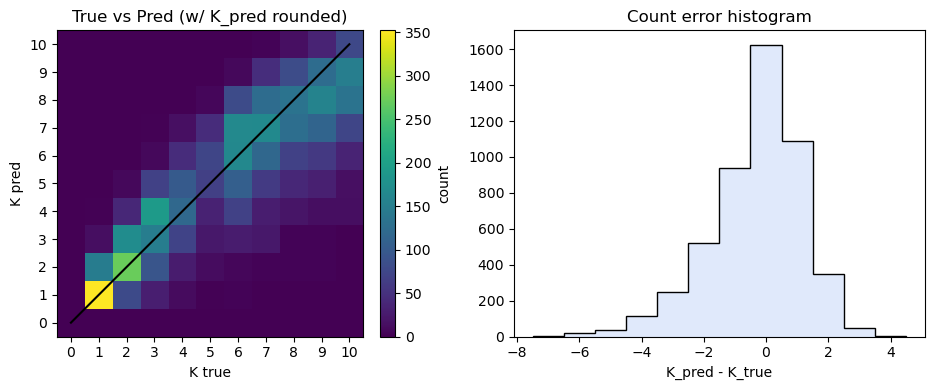

In [7]:
#### visualizing (spectackle: collect_count_predictions_b)
y_true, y_pred = collect_count_predictions_b(model, val_loader, device=device, Kmax=Kmax, max_batches=50)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))



# true vs pred
# true vs pred (2D histogram instead of scatter)
edges = np.arange(-0.5, Kmax + 1.5, 1.0)  # integer-centered bins: 0..Kmax
H, xedges, yedges = np.histogram2d(y_true, y_pred, bins=[edges, edges])

im = axes[0].imshow(
    H.T,
    origin="lower",
    aspect="equal",
    interpolation="nearest",
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
)

axes[0].plot([0, Kmax], [0, Kmax], lw=1.5, color="k")
axes[0].set_xlabel("K true")
axes[0].set_ylabel("K pred")
axes[0].set_title("True vs Pred (w/ K_pred rounded)")

ticks = np.arange(0, Kmax + 1, 1)
axes[0].set_xticks(ticks)
axes[0].set_yticks(ticks)

# colorbar for the left panel
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="count")

# error histogram
err = (y_pred - y_true)
axes[1].hist(err, bins=np.arange(err.min()-0.5, err.max()+1.5, 1), color='cornflowerblue', alpha=0.2)
axes[1].hist(err, bins=np.arange(err.min()-0.5, err.max()+1.5, 1),histtype='step',color='k',lw=1)

axes[1].set_xlabel("K_pred - K_true")
axes[1].set_title("Count error histogram")

plt.tight_layout()
plt.show()
plt.close(fig)


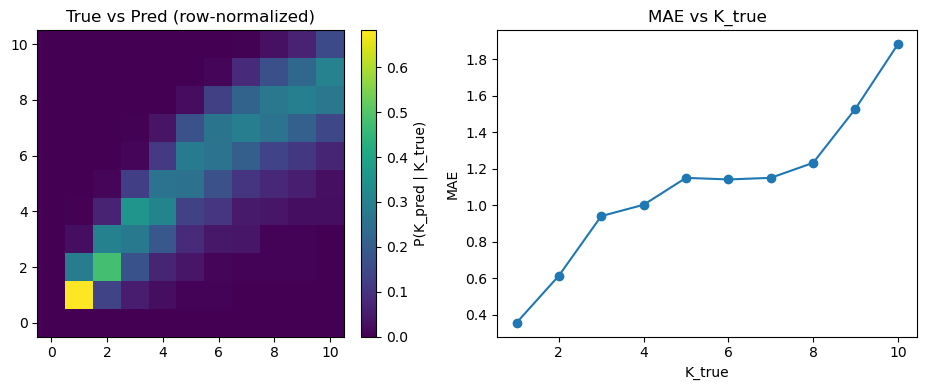

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

### Row-normalized 2D histogram
Hn = H / (H.sum(axis=1, keepdims=True) + 1e-12)

im = axes[0].imshow(
    Hn.T,
    origin="lower",
    aspect="equal",
    interpolation="nearest",
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
)
axes[0].set_title("True vs Pred (row-normalized)")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="P(K_pred | K_true)")

### MAE vs K_true
mae_by_k = []
ks = np.arange(0, Kmax + 1)
for k in ks:
    m = (y_true == k)
    mae_by_k.append(np.mean(np.abs(y_pred[m] - y_true[m])) if np.any(m) else np.nan)

axes[1].plot(ks, mae_by_k, marker="o")
axes[1].set_xlabel("K_true")
axes[1].set_ylabel("MAE")
axes[1].set_title("MAE vs K_true")
plt.tight_layout()
plt.show()
